### Linear Regression
In this notebook I will develop my first Machine Learning regression model by applying Linear Regression.The objective is to predict the score of students in their final exam using various factors:
- Train the model.
- Evaluate its performance.
- Compare it with simple baseline.
- interpret the model coefficients.

## Import Libraries

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## Load Dataset

In [4]:
df=pd.read_csv("student_performance_dataset.csv")
df.head(10)

,student_id,gender,study_time_hours,attendance_percent,sleep_hours,parental_education,internet_access,extracurricular_activities,part_time_job,previous_grade,final_exam_score,final_grade
0,1,Male,4.0,98.0,6.5,Bachelors,Yes,Yes,No,76.9,100.0,A
1,2,Female,6.3,100.0,5.7,High School,Yes,Yes,Yes,75.5,100.0,A
2,3,Male,4.9,85.3,7.9,Bachelors,Yes,No,Yes,88.5,97.3,A
3,4,Male,2.6,77.5,8.0,NaN,Yes,Yes,No,85.1,83.8,B
4,5,Male,2.2,89.6,4.6,Bachelors,Yes,No,Yes,61.8,68.3,D
5,6,Female,4.2,78.2,5.7,High School,Yes,No,No,79.8,81.6,B
6,7,Male,1.5,100.0,5.0,High School,Yes,Yes,Yes,58.6,69.6,D
7,8,Male,6.2,86.4,6.0,High School,Yes,Yes,No,78.4,88.0,B
8,9,Male,5.3,81.3,6.7,Bachelors,Yes,No,No,63.8,84.4,B
9,10,Female,2.8,86.8,5.1,Bachelors,Yes,Yes,No,57.7,74.3,C


Linear Regression expect numeric inputs ,since some columns in the dataset have string values we need to convert them to numeric values for model training. 

In [15]:
x.select_dtypes(include="object").columns

C:\Users\Ayman\AppData\Local\Temp\ipykernel_20300\930013236.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  x.select_dtypes(include="object").columns


Index(['gender', 'parental_education', 'internet_access',
       'extracurricular_activities', 'part_time_job', 'final_grade'],
      dtype='str')

## Selecting Features
The target variable is final_exam_score ,so the remaining columns will be used as input features.

In [17]:
x=df.drop(["final_exam_score","final_grade"],axis=1)
x=pd.get_dummies(x,drop_first=True) ##convert the columns into numerical
y=df["final_exam_score"]
print(x.shape)
print(y.shape)

(1000, 12)
(1000,)


Drop the column Final_exam_score because its the target variable.
Drop the column final grade because it is derived from the final score and hence will result in data leakage while training the model.

In [18]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(800, 12)
(200, 12)
(800,)
(200,)


## Training-Testing split
The dataset is split between the training and testing datasets,the training dataset is employed for training the model and the testing dataset is employed for assessing the model's performance on new data

## Build the linear Regression Model


In [19]:
model=LinearRegression()

## Training the Model
The model is trained to learn the mapping between inputs and outputs variables.

In [20]:
model.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](12,)","[ 0. , 4.12, 0.33,..., 5.99, 0.83,-3.6 ]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](12,)","['student_id','study_time_hours','attendance_percent',..., 'internet_access_Yes','extracurricular_activities_Yes', 'part_time_job_Yes']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,4.15
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,12
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(12)


## Generate Predictions

In [21]:
predictions=model.predict(x_test)

In [22]:
predictions[:10]

array([78.04629387, 73.63526585, 73.74362684, 91.03078568, 88.51402361,
       70.53318413, 93.53622089, 73.96126108, 73.01523601, 65.52062802])

The first 10 values the  trained model predicted.

### Compare the actual value with the predicted value
## (Quick Check)

In [24]:
comparison=pd.DataFrame({
    "Actual":y_test.values,
    "Predicted" :predictions
})
comparison.head(10)

,Actual,Predicted
0,71.8,78.046294
1,66.6,73.635266
2,62.9,73.743627
3,95.2,91.030786
4,90.2,88.514024
5,63.6,70.533184
6,96.8,93.536221
7,77.9,73.961261
8,66.5,73.015236
9,59.7,65.520628


Create a DataFrame to compare the actual score with the model prediction.

## Plot the actual and predicted values

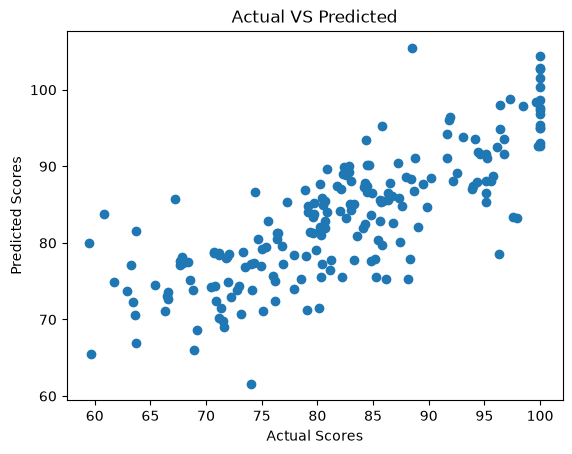

In [29]:
plt.scatter(y_test,predictions)
plt.xlabel("Actual Scores")
plt.ylabel("Predicted Scores")
plt.title("Actual VS Predicted")
plt.show()

## Coefficients
Each cofficients shows the change in the estimated output when the feature change by one unit,holding all other features constant

In [ ]:
Coefficients = pd.DataFrame({
    "Feature": x.columns,
    "Coefficients": model.coef_
})
Coefficients.sort_values("Coefficients", ascending=False)

,Feature,Coefficients
9,internet_access_Yes,5.993207
1,study_time_hours,4.115219
8,parental_education_PhD,1.181787
3,sleep_hours,1.014330
7,parental_education_Masters,0.946842
10,extracurricular_activities_Yes,0.826147
6,parental_education_High School,0.447238
4,previous_grade,0.350857
2,attendance_percent,0.334777
0,student_id,0.000558


## Intercept

In [37]:
print("Intercept:",model.intercept_)

Intercept: 4.150110151343455


Display the bias term of the Linear Regression model.

## Model Evaluation

In [40]:
mae=mean_absolute_error(y_test,predictions)
rmse=np.sqrt(mean_squared_error(y_test,predictions))
r2=r2_score(y_test,predictions)
print("MAE:",mae)
print("RMSE:",rmse)
print("R^2:",r2)

MAE: 4.985504963921428
RMSE: 6.415777608907253
R^2: 0.6175830013464343


## Baseline Model
baseline predicts the mean of the training target for every test sample

In [41]:
baseline_prediction=np.full(len(y_test),y_train.mean())

## Baseline RMSE

In [45]:
baseline_rmse=np.sqrt(mean_squared_error(y_test,baseline_prediction))

## Compare the model with the Baseline

In [47]:
print("Model RMSE:",rmse)
print("Baseline RMSE:",baseline_rmse)
if rmse < baseline_rmse:
    print("Linear Regression performs better than the baseline")
else:
    print("baseline performs better than the Linear Regression")

Model RMSE: 6.415777608907253
Baseline RMSE: 10.501313382144156
Linear Regression performs better than the baseline


## Find the strongest feature

In [52]:
Coefficients["Absolute"] = Coefficients["Coefficients"].abs()
Coefficients.sort_values("Absolute", ascending=False)

,Feature,Coefficients,Absolute
9,internet_access_Yes,5.993207,5.993207
1,study_time_hours,4.115219,4.115219
11,part_time_job_Yes,-3.603802,3.603802
8,parental_education_PhD,1.181787,1.181787
3,sleep_hours,1.014330,1.014330
7,parental_education_Masters,0.946842,0.946842
10,extracurricular_activities_Yes,0.826147,0.826147
6,parental_education_High School,0.447238,0.447238
4,previous_grade,0.350857,0.350857
2,attendance_percent,0.334777,0.334777


## Hands-On-Lab
- Step 1: Train a LinearRegression model on a provided regression dataset (e.g. house prices).

Linear Regression model was created using the training dataset and predictions were made using the test dataset.

- Step 2: Report the model's coefficients and identify which feature has the strongest effect.

In [53]:
Coefficients.sort_values("Absolute", ascending=False)

,Feature,Coefficients,Absolute
9,internet_access_Yes,5.993207,5.993207
1,study_time_hours,4.115219,4.115219
11,part_time_job_Yes,-3.603802,3.603802
8,parental_education_PhD,1.181787,1.181787
3,sleep_hours,1.014330,1.014330
7,parental_education_Masters,0.946842,0.946842
10,extracurricular_activities_Yes,0.826147,0.826147
6,parental_education_High School,0.447238,0.447238
4,previous_grade,0.350857,0.350857
2,attendance_percent,0.334777,0.334777


The feature that has the largest absolute coefficient is (internet_access_Yes) it is  the most significant because an increase in the value
of the feature by unite has a greater effect on the output compared to any other feature. 

- Step 3: Evaluate the model with MAE, RMSE, and R² on the test set.

The model was evaluated using three regression metrics:
- MAE=4.99 on average prediction made by the model vary from the actual exam score by 5 points.
- RMSE=6.42 the model makes an average prediction error of 6.4 points with bigger errors being weighted more heavily.
- R^2=0.62 the model accounts for 61.8% of the variations in exam score of the students.

- Step 4: Compare the RMSE against a baseline that predicts the mean for every row, and state whether the
model adds value.

In [54]:
print("Model RMSE:",rmse)
print("Baseline RMSE:",baseline_rmse)
if rmse < baseline_rmse:
    print("Linear Regression performs better than the baseline")
else:
    print("baseline performs better than the Linear Regression")

Model RMSE: 6.415777608907253
Baseline RMSE: 10.501313382144156
Linear Regression performs better than the baseline


As the linear Regression model obtains a signficantly smaller RMSE compared to the baseline it makes more accurate predictions and effectively learns patterns from the dataset ,so the model is more valuable than predicting the average score for each student. 

- Step 5: Document the interpretation of results in Markdown.

- The linear Regression model successfully predicts the final exam score of students based on several inputs features.
- The cofficients shows how each feature affects the prediction and the model is quite easy to interpret.
- The Evaluation metric helped in assess the accuracy of the predicition and comparing it with the baseline ensured that the model adds value to the prediction.
Linear Regression works as an excellent baseline model for predicting continous values.